In [8]:
# CELL 1: Global Setup
# ═══════════════════════════════════════════════════════════════════════════════
# All constants, colors, and helpers needed by subsequent cells.
# Canonical: 4 categories (face, house, object, word).
# PPA/TOS split available for future supplemental work (commented out).
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.linalg import orthogonal_procrustes
from scipy import stats as sp_stats

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path(processed_dir)
SEL_DIR = BASE / 'group_results' / 'selectivity'
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Cope set ──────────────────────────────────────────────────────────────────
COPE_SET = 'differential'

# ── Group colors ──────────────────────────────────────────────────────────────
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L  = '#7398af'
OTC_R  = '#ee7183'
NONOT  = '#FF9800'

# ── Categories (canonical: 4) ─────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL  = ['house', 'object']
UNILATERAL = ['face', 'word']

CAT_COLORS = {
    'face':   '#cc0066',   # magenta
    'word':   '#ff8800',   # orange
    'house':  '#009900',   # green
    'object': '#0077cc',   # blue
}

CAT_MARKERS = {
    'face':   'o',
    'word':   's',
    'house':  '^',
    'object': 'D',
}

# ── Reorganized category per resection side ───────────────────────────────────
REORG = {'left': 'word', 'right': 'face'}

# ── Preferred control hemisphere for Crawford comparisons ─────────────────────
PREFERRED_CTRL_HEMI = {
    'face':   'right',
    'word':   'left',
    'house':  'left',
    'object': 'left',
}

# ── Preferred hemisphere for neural heatmap projection ────────────────────────
PREF_HEMI_NEURAL = {
    'face':   'right',
    'word':   'left',
    'house':  'right',
    'object': 'left',
}

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

RNG = np.random.default_rng(42)

# ── Shared helpers ────────────────────────────────────────────────────────────

def short_name(code):
    """Compact subject label for plot annotations."""
    return (code.replace('OTC', '').replace('nonOTC', 'n')
                .replace('control', 'c').replace('sub-', ''))


def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    """1-SD covariance ellipse for scatter (x, y). Needs >= 3 points."""
    if len(x) < 3:
        return
    cov     = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry  = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx      = np.sqrt(cov[0, 0]) * n_std
    sy      = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


# ── PPA/TOS extension (peak coords + supplemental) ───────────────────────────
CATEGORIES_PEAK = ['face', 'house_PPA', 'house_TOS', 'object', 'word']
CAT_COLORS_PEAK = {
    **CAT_COLORS,
    'house_PPA': '#005500',   # dark green
    'house_TOS': '#66cc00',   # yellow-green
}
CAT_MARKERS_PEAK = {
    **CAT_MARKERS,
    'house_PPA': '^',
    'house_TOS': 'v',
}
PREFERRED_CTRL_HEMI_PEAK = {
    **PREFERRED_CTRL_HEMI,
    'house_PPA': 'left',
    'house_TOS': 'left',
}

print(f'Setup complete. COPE_SET={COPE_SET}')
print(f'CATEGORIES: {CATEGORIES}')

Setup complete. COPE_SET=differential
CATEGORIES: ['face', 'house', 'object', 'word']


In [9]:
# CELL 2: Crawford Helpers + Shared Data Loaders
# ═══════════════════════════════════════════════════════════════════════════════

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test: single case vs controls.
    Returns (t_stat, p_val, n_controls)."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    p = 2 * sp_stats.t.sf(abs(t), df=n - 1)
    return t, p, n


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns boolean rejected array."""
    pvals = np.asarray(pvals, dtype=float)
    n     = len(pvals)
    if n == 0: 
        return np.array([], dtype=bool)
    order    = np.argsort(pvals)
    ranked   = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


def load_liu_first_session(cope_set=COPE_SET):
    """Load liu_distinctiveness CSV; return (ctrl, otc) first-session DataFrames."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return None, None
    df    = pd.read_csv(liu_file)
    first = (df.groupby('subject_id')['session'].min()
               .reset_index().rename(columns={'session': 'fs'}))
    df    = df.merge(first, on='subject_id')
    df    = df[df['session'] == df['fs']]
    ctrl  = df[df['status'] == 'control'].copy()
    otc   = df[(df['group'] == 'OTC') & (df['hemi_label'] == 'intact')].copy()
    return ctrl, otc


def compute_crawford_rows(ctrl, otc):
    """Crawford t/p for every patient x category.
    Returns DataFrame: subject, surgery_side, category, t, p, sig (BH-FDR)."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi  = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values
        for _, row in otc[otc['category'] == cat].iterrows():
            t, p, _ = crawford_t(row['liu_distinctiveness'], ctrl_vals)
            rows.append({'subject': row['subject'],
                         'surgery_side': row['surgery_side'],
                         'category': cat, 't': t, 'p': p})
    cdf   = pd.DataFrame(rows)
    valid = cdf['p'].notna()
    cdf['sig'] = False
    if valid.sum() > 0:
        cdf.loc[valid, 'sig'] = bh_fdr(cdf.loc[valid, 'p'].values)
    return cdf


print('Crawford helpers and data loaders ready.')

Crawford helpers and data loaders ready.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: Load Selectivity + Bootstrap Data
# ═══════════════════════════════════════════════════════════════════════════════

RESAMPLE_DIR = SEL_DIR / 'resamples'
METRIC = 'sum_selec_norm'

sel_file = SEL_DIR / 'selectivity_summary.csv'
resample_file = RESAMPLE_DIR / f'{METRIC}_resamples.csv'

for f, label in [(sel_file, 'selectivity_summary'), (resample_file, 'resamples')]:
    if not f.exists():
        print(f'MISSING: {f}')

df_sel = pd.read_csv(sel_file)
df_boot = pd.read_csv(resample_file)

# First session only
df_sel['ses_int'] = df_sel['ses'].astype(int)
first = df_sel.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
df_sel = df_sel.merge(first, on='sub')
df_sel = df_sel[df_sel['ses_int'] == df_sel['fs']]

ctrl   = df_sel[df_sel['group'] == 'control'].copy()
otc    = df_sel[df_sel['group'] == 'OTC'].copy()
nonotc = df_sel[df_sel['group'] == 'nonOTC'].copy()

otc['surgery_side'] = otc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')
nonotc['surgery_side'] = nonotc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')

# Pivot controls for lateralization tests
ctrl_wide = {}
for cat in CATEGORIES:
    cat_df = ctrl[ctrl['category'] == cat][['sub', 'hemi', METRIC]]
    pivoted = cat_df.pivot(index='sub', columns='hemi', values=METRIC).dropna()
    ctrl_wide[cat] = pivoted

# Preferred/non-preferred for bootstrap lookups
PREFERRED_HEMI = PREFERRED_CTRL_HEMI  # from Cell 1
NON_PREFERRED_HEMI = {k: ('left' if v == 'right' else 'right') for k, v in PREFERRED_HEMI.items()}

print(f'Controls: {ctrl["sub"].nunique()}, OTC: {otc["sub"].nunique()}, '
      f'nonOTC: {nonotc["sub"].nunique()}')
print(f'Bootstrap: {df_boot.shape[0]} iterations, {df_boot.shape[1]} columns')

Controls: 24, OTC: 17, nonOTC: 9
Bootstrap: 10000 iterations, 26 columns


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Controls Lateralization
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.stats import ttest_rel, ttest_ind

n_comparisons = len(CATEGORIES)
bonferroni_alpha = 0.05 / n_comparisons

print('='*70)
print('CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)')
print('='*70)

lat_results = {}
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    lh, rh = piv['left'].values, piv['right'].values
    n = len(lh)
    diff = lh - rh
    t_stat, t_p = ttest_rel(lh, rh)
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    bonf_sig = t_p < bonferroni_alpha
    direction = 'LH > RH' if diff.mean() > 0 else 'RH > LH'
    cat_type = 'unilateral' if cat in UNILATERAL else 'bilateral'

    lat_results[cat] = {'t': t_stat, 'p': t_p, 'd': d, 'sig': bonf_sig, 'dir': direction}

    print(f'\n  {cat} ({cat_type}): n={n}')
    print(f'    LH: M={lh.mean():.1f} (SD={lh.std():.1f})')
    print(f'    RH: M={rh.mean():.1f} (SD={rh.std():.1f})')
    print(f'    t({n-1}) = {t_stat:.3f}, p = {t_p:.4f}, d = {d:.3f}')
    print(f'    Bonferroni (α={bonferroni_alpha:.4f}): '
          f'{"SIGNIFICANT" if bonf_sig else "ns"} — {direction}')

CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)

  face (unilateral): n=24
    LH: M=299.4 (SD=227.2)
    RH: M=493.0 (SD=420.6)
    t(23) = -2.914, p = 0.0078, d = -0.608
    Bonferroni (α=0.0125): SIGNIFICANT — RH > LH

  house (bilateral): n=24
    LH: M=499.5 (SD=325.4)
    RH: M=624.9 (SD=398.7)
    t(23) = -2.764, p = 0.0111, d = -0.576
    Bonferroni (α=0.0125): SIGNIFICANT — RH > LH

  object (bilateral): n=24
    LH: M=1942.0 (SD=847.3)
    RH: M=1759.7 (SD=895.4)
    t(23) = 2.450, p = 0.0223, d = 0.511
    Bonferroni (α=0.0125): ns — LH > RH

  word (unilateral): n=24
    LH: M=164.3 (SD=199.3)
    RH: M=29.8 (SD=34.0)
    t(23) = 3.281, p = 0.0033, d = 0.684
    Bonferroni (α=0.0125): SIGNIFICANT — LH > RH


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Individual Patient Bootstrap (Ayzenberg Method)
#
# PRIMARY:   patient intact hemi vs. controls' PREFERRED hemi
#            → within/above CI = evidence of reorganization
# SECONDARY: patient intact hemi vs. controls' NON-PREFERRED hemi
#            → above non-preferred = STRONG evidence of reorganization
# ═══════════════════════════════════════════════════════════════════════════════

print('='*70)
print('INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method)')
print('  Primary:   intact vs. controls preferred hemi')
print('  Secondary: intact vs. controls non-preferred hemi')
print('  Reorg interpretation:')
print('    within preferred CI         → reorganization')
print('    also above non-preferred CI → STRONG reorganization')
print('    below preferred CI          → impaired')
print('='*70)

corrected_rows = []

for grp_label in ['OTC', 'nonOTC']:
    grp_df = otc if grp_label == 'OTC' else nonotc
    if grp_df.empty:
        continue

    print(f'\n{"="*70}\n  {grp_label}\n{"="*70}')

    for sub in sorted(grp_df['sub'].unique()):
        sub_data = grp_df[grp_df['sub'] == sub]
        intact = sub_data['intact_hemi'].iloc[0]

        print(f'\n  {sub} (intact {intact}):')

        for cat in CATEGORIES:
            pt_row = sub_data[sub_data['category'] == cat]
            if pt_row.empty:
                print(f'    {cat}: no data')
                continue
            pt_val = pt_row[METRIC].values[0]

            pref = PREFERRED_HEMI[cat]
            nonpref = NON_PREFERRED_HEMI[cat]
            is_reorg = (intact != pref)
            test_type = 'reorg' if is_reorg else 'normal'

            # ── Primary: vs preferred ─────────────────────────────────────
            pref_col = f'{cat}_{pref}'
            pref_dist = df_boot[pref_col].dropna().values
            pref_pctile = float(np.mean(pref_dist <= pt_val) * 100)
            pref_ci_lo = np.percentile(pref_dist, 2.5)
            pref_ci_hi = np.percentile(pref_dist, 97.5)
            below_pref = pt_val < pref_ci_lo

            # ── Secondary: vs non-preferred ───────────────────────────────
            nonpref_col = f'{cat}_{nonpref}'
            nonpref_dist = df_boot[nonpref_col].dropna().values
            nonpref_pctile = float(np.mean(nonpref_dist <= pt_val) * 100)
            nonpref_ci_lo = np.percentile(nonpref_dist, 2.5)
            nonpref_ci_hi = np.percentile(nonpref_dist, 97.5)
            above_nonpref = pt_val > nonpref_ci_hi

            # ── Interpretation ────────────────────────────────────────────
            if is_reorg:
                if not below_pref and above_nonpref:
                    interp = 'STRONG reorg'
                elif not below_pref:
                    interp = 'reorg (within preferred)'
                else:
                    interp = 'impaired'
            else:
                if not below_pref:
                    interp = 'normal'
                else:
                    interp = 'impaired'

            pref_marker = '*' if below_pref else '-'
            nonpref_marker = '+' if above_nonpref else '-'

            print(f'    {cat} [{test_type}]: val={pt_val:.0f}  '
                  f'vs pref({pref})={pref_pctile:.0f}%{pref_marker}  '
                  f'vs nonpref({nonpref})={nonpref_pctile:.0f}%{nonpref_marker}  '
                  f'→ {interp}')

            corrected_rows.append({
                'sub': sub, 'group': grp_label, 'intact_hemi': intact,
                'category': cat, 'value': pt_val, 'test_type': test_type,
                'pref_hemi': pref, 'pref_pctile': pref_pctile,
                'pref_ci_lo': pref_ci_lo, 'pref_ci_hi': pref_ci_hi,
                'below_pref': below_pref,
                'nonpref_hemi': nonpref, 'nonpref_pctile': nonpref_pctile,
                'nonpref_ci_lo': nonpref_ci_lo, 'nonpref_ci_hi': nonpref_ci_hi,
                'above_nonpref': above_nonpref,
                'interpretation': interp,
            })

df_corrected = pd.DataFrame(corrected_rows)

# ── Summary: Reorganization tests ─────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Reorganization tests (intact = non-preferred hemi)')
print('='*70)
for grp_label in ['OTC', 'nonOTC']:
    grp = df_corrected[(df_corrected['group'] == grp_label) &
                        (df_corrected['test_type'] == 'reorg')]
    print(f'\n  {grp_label}:')
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"above_nonpref":>14} {"STRONG":>7}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        n_within = int((~c['below_pref']).sum())
        n_above = int(c['above_nonpref'].sum())
        n_strong = int(((~c['below_pref']) & c['above_nonpref']).sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_above:>10}/{n:<3} {n_strong:>4}/{n}')

# ── Summary: Normal tests ─────────────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Normal tests (intact = preferred hemi)')
print('='*70)
for grp_label in ['OTC', 'nonOTC']:
    grp = df_corrected[(df_corrected['group'] == grp_label) &
                        (df_corrected['test_type'] == 'normal')]
    print(f'\n  {grp_label}:')
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"impaired":>9}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        n_within = int((~c['below_pref']).sum())
        n_impaired = int(c['below_pref'].sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_impaired:>5}/{n}')

INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method)
  Primary:   intact vs. controls preferred hemi
  Secondary: intact vs. controls non-preferred hemi
  Reorg interpretation:
    within preferred CI         → reorganization
    also above non-preferred CI → STRONG reorganization
    below preferred CI          → impaired

  OTC

  sub-004 (intact left):
    face [reorg]: val=28  vs pref(right)=0%*  vs nonpref(left)=0%-  → impaired
    house [normal]: val=318  vs pref(left)=14%-  vs nonpref(right)=6%-  → normal
    object [normal]: val=361  vs pref(left)=0%*  vs nonpref(right)=0%-  → impaired
    word [normal]: val=3  vs pref(left)=0%*  vs nonpref(right)=3%-  → impaired

  sub-008 (intact left):
    face [reorg]: val=966  vs pref(right)=98%-  vs nonpref(left)=100%+  → STRONG reorg
    house [normal]: val=643  vs pref(left)=80%-  vs nonpref(right)=55%-  → normal
    object [normal]: val=715  vs pref(left)=0%*  vs nonpref(right)=1%-  → impaired
    word [normal]: val=18  vs pref(left)=2%*  v

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Group-Level Comparisons
#
# 6a: Patient group mean vs. bootstrapped preferred-hemi controls
# 6b: Within-group hemisphere differences
# ═══════════════════════════════════════════════════════════════════════════════

# ── 6a: Group mean vs bootstrap ──────────────────────────────────────────────
print('='*70)
print('6a. GROUP-LEVEL BOOTSTRAP: patient group mean vs controls preferred hemi')
print('='*70)

for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} vs Controls (preferred hemi) ---')
    for cat in CATEGORIES:
        pt_vals = grp_df[grp_df['category'] == cat][METRIC].dropna().values
        if len(pt_vals) == 0:
            continue
        pt_mean = pt_vals.mean()

        pref = PREFERRED_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == pref)][METRIC].values
        ctrl_mean = ctrl_vals.mean()
        ctrl_sd = ctrl_vals.std(ddof=1)

        boot_col = f'{cat}_{pref}'
        boot_dist = df_boot[boot_col].dropna().values
        pt_pctile = float(np.mean(boot_dist <= pt_mean) * 100)
        ci_lo = np.percentile(boot_dist, 2.5)
        ci_hi = np.percentile(boot_dist, 97.5)
        below = pt_mean < ci_lo

        d = (pt_mean - ctrl_mean) / ctrl_sd if ctrl_sd > 0 else np.nan
        sig_str = '**BELOW CI**' if below else 'within CI'

        print(f'  {cat}: pt M={pt_mean:.1f} (n={len(pt_vals)}), '
              f'ctrl {pref} M={ctrl_mean:.1f} (n={len(ctrl_vals)})')
        print(f'    pctile={pt_pctile:.1f}%, CI=[{ci_lo:.1f}, {ci_hi:.1f}] — {sig_str}, Δ={d:.3f}')

# ── 6b: Within-group hemisphere differences ──────────────────────────────────
print('\n' + '='*70)
print('6b. WITHIN-GROUP HEMISPHERE DIFFERENCES')
print('='*70)

# Controls: paired t-test (same subjects, both hemispheres)
print('\n--- Controls (paired t-test, LH vs RH) ---')
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    t, p = ttest_rel(piv['left'].values, piv['right'].values)
    diff = piv['left'].values - piv['right'].values
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {cat}: LH M={piv["left"].mean():.1f}, RH M={piv["right"].mean():.1f}, '
          f't({len(piv)-1})={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

# OTC/nonOTC: independent t-test (L resection vs R resection = different patients)
for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} (independent t-test, L vs R resection) ---')
    for cat in CATEGORIES:
        l_vals = grp_df[(grp_df['category'] == cat) &
                        (grp_df['surgery_side'] == 'left')][METRIC].dropna().values
        r_vals = grp_df[(grp_df['category'] == cat) &
                        (grp_df['surgery_side'] == 'right')][METRIC].dropna().values
        if len(l_vals) < 2 or len(r_vals) < 2:
            print(f'  {cat}: L resec n={len(l_vals)}, R resec n={len(r_vals)} — too few')
            continue
        t, p = ttest_ind(l_vals, r_vals)
        pooled_sd = np.sqrt(((len(l_vals)-1)*l_vals.std(ddof=1)**2 +
                             (len(r_vals)-1)*r_vals.std(ddof=1)**2) /
                            (len(l_vals)+len(r_vals)-2))
        d = (l_vals.mean() - r_vals.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {cat}: L resec(intact RH) M={l_vals.mean():.1f}(n={len(l_vals)}), '
              f'R resec(intact LH) M={r_vals.mean():.1f}(n={len(r_vals)}), '
              f't={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

6a. GROUP-LEVEL BOOTSTRAP: patient group mean vs controls preferred hemi

--- OTC vs Controls (preferred hemi) ---
  face: pt M=409.5 (n=17), ctrl right M=493.0 (n=24)
    pctile=39.0%, CI=[163.4, 954.9] — within CI, Δ=-0.194
  house: pt M=469.6 (n=17), ctrl left M=499.5 (n=24)
    pctile=45.4%, CI=[219.3, 842.4] — within CI, Δ=-0.090
  object: pt M=1230.6 (n=17), ctrl left M=1942.0 (n=24)
    pctile=4.5%, CI=[1125.6, 2782.0] — within CI, Δ=-0.822
  word: pt M=118.8 (n=17), ctrl left M=164.3 (n=24)
    pctile=38.0%, CI=[18.0, 400.4] — within CI, Δ=-0.223

--- nonOTC vs Controls (preferred hemi) ---
  face: pt M=675.2 (n=9), ctrl right M=493.0 (n=24)
    pctile=80.6%, CI=[163.4, 954.9] — within CI, Δ=0.424
  house: pt M=707.2 (n=9), ctrl left M=499.5 (n=24)
    pctile=88.8%, CI=[219.3, 842.4] — within CI, Δ=0.625
  object: pt M=1612.1 (n=9), ctrl left M=1942.0 (n=24)
    pctile=21.4%, CI=[1125.6, 2782.0] — within CI, Δ=-0.381
  word: pt M=75.0 (n=9), ctrl left M=164.3 (n=24)
    pctile=

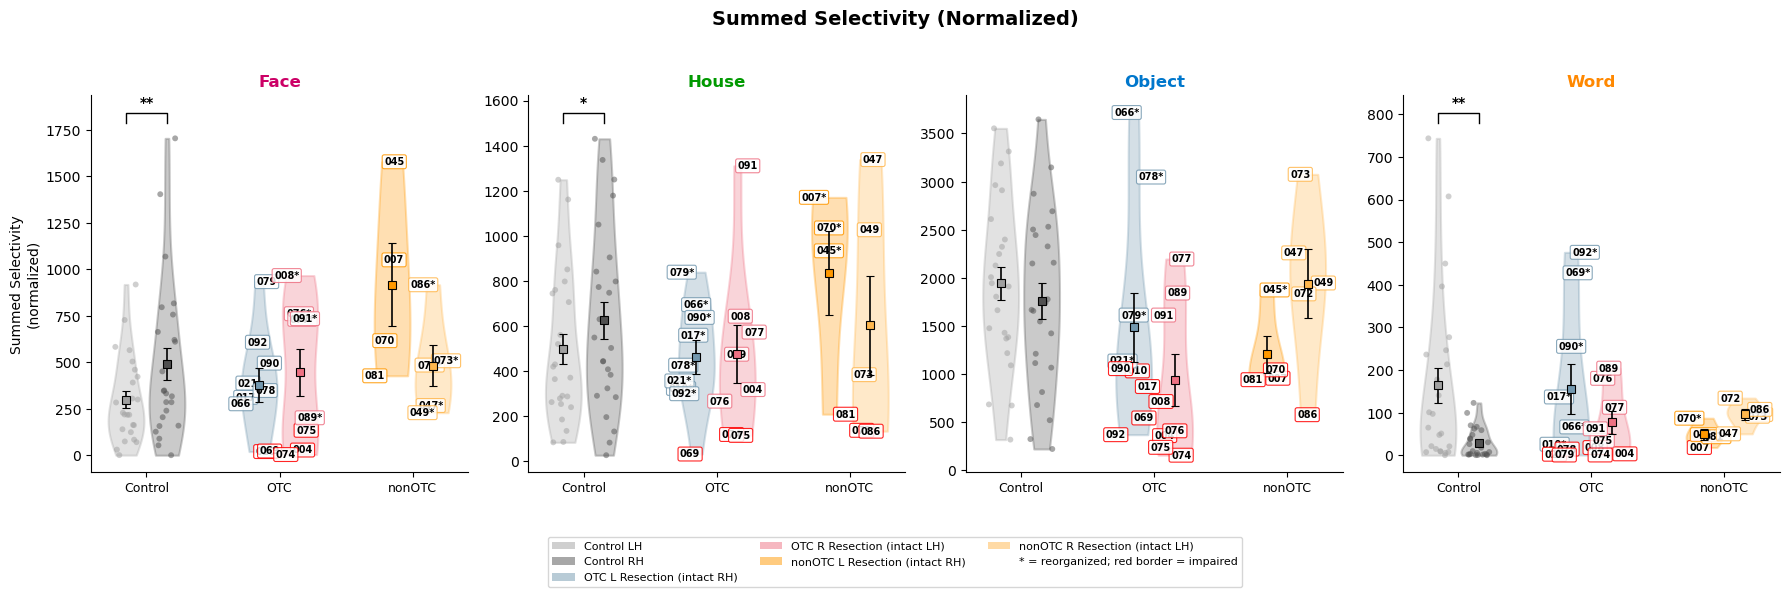

Saved: fig_selectivity_sum_selec_norm.png


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Figure — Summed Selectivity
# Controls L/R | OTC L/R resection | nonOTC L/R resection
# Patient labels: * = reorganized, red border = impaired
# ═══════════════════════════════════════════════════════════════════════════════

n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Lateralization bracket ────────────────────────────────────────────
    if cat in lat_results and lat_results[cat]['sig']:
        y_max = max(cl.max() if len(cl) else 0, cr.max() if len(cr) else 0)
        bracket_y = y_max * 1.05
        ax.plot([0.0, 0.0, 0.4, 0.4],
                [bracket_y, bracket_y*1.03, bracket_y*1.03, bracket_y],
                color='black', linewidth=1, clip_on=False)
        p = lat_results[cat]['p']
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(0.2, bracket_y*1.04, sig_str,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            lbl = short_name(row['sub'])

            pt_interp = df_corrected[(df_corrected['sub'] == row['sub']) &
                                      (df_corrected['category'] == cat)]
            if not pt_interp.empty:
                interp = pt_interp['interpretation'].values[0]
                star = '*' if 'reorg' in interp.lower() else ''
                edge = 'red' if interp == 'impaired' else color
            else:
                star, edge = '', color

            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=edge, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals)/np.sqrt(max(len(vals),1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── nonOTC Left/Right resection ───────────────────────────────────────
    for side, pos, fc in [('left', 2.6, NONOT), ('right', 3.0, '#FFB74D')]:
        sd = nonotc[(nonotc['category'] == cat) & (nonotc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(fc)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            lbl = short_name(row['sub'])

            pt_interp = df_corrected[(df_corrected['sub'] == row['sub']) &
                                      (df_corrected['category'] == cat)]
            if not pt_interp.empty:
                interp = pt_interp['interpretation'].values[0]
                star = '*' if 'reorg' in interp.lower() else ''
                edge = 'red' if interp == 'impaired' else fc
            else:
                star, edge = '', fc

            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=edge, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals)/np.sqrt(max(len(vals),1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=fc, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    ax.set_xticks([0.2, 1.5, 2.8])
    ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold', color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('Summed Selectivity\n(normalized)')

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC L Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC R Resection (intact LH)'),
    Patch(facecolor=NONOT,  alpha=0.5, label='nonOTC L Resection (intact RH)'),
    Patch(facecolor='#FFB74D', alpha=0.5, label='nonOTC R Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized; red border = impaired'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Summed Selectivity (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_selectivity_{METRIC}.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_selectivity_{METRIC}.png')